In [ ]:
import tensorflow as tf

In [ ]:
# one hot encoding (depth3 -> 0,1,2 표현가능)
tf.print(tf.one_hot([0,1,2,0], depth=3))

[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]]


In [ ]:
# type casting (int는 소수점 버림)
tf.print(tf.cast([1.8, 2.2, 3.3, 4.9], tf.int32))
tf.print(tf.cast([True, False, 1 == 1, 0 == 1], tf.int32))

[1 2 3 4]
[1 0 1 0]


In [ ]:
x=[[0,1,2],
   [2,1,0]]
tf.print(tf.ones_like(x))

[[1 1 1]
 [1 1 1]]


---
# **Single-Layer Perceptron**


In [ ]:
import tensorflow as tf

In [ ]:
# 고정된 X,Y와 학습하면서 update되는 W,b

X = tf.constant([1, 2, 3], dtype=tf.float32)
Y = tf.constant([1, 2, 3], dtype=tf.float32)
W = tf.Variable(tf.random.uniform([1], -1.0, 1.0))
b = tf.Variable(tf.random.uniform([1], -1.0, 1.0))

In [ ]:
# 모델, x가 들어오면 Y_pred를 return
def hypothesis(X):
    return W * X + b

# MSE(최소제곱오차)식
def cost(Y_pred, Y):
    return tf.reduce_mean(tf.square(Y_pred - Y))

# 최적화 도구로 gradient descent 사용
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

In [ ]:
# full batch
for epoch in range(100):
    with tf.GradientTape() as tape:
        Y_pred = hypothesis(X)
        current_loss = cost(Y_pred, Y)
    gradients = tape.gradient(current_loss, [W, b])
    optimizer.apply_gradients(zip(gradients, [W, b]))
    print(epoch, current_loss.numpy(), W.numpy(), b.numpy())

0 6.2896075 [1.3166752] [-0.43163007]
1 0.10754651 [1.1937637] [-0.47197413]
2 0.03216083 [1.2017072] [-0.4550848]
3 0.029793682 [1.1954811] [-0.44475073]
4 0.028368441 [1.1909324] [-0.433993]
5 0.027020803 [1.186326] [-0.42356738]
6 0.02573731 [1.1818486] [-0.41338432]
7 0.024514755 [1.177477] [-0.4034469]
8 0.023350298 [1.1732105] [-0.39374834]
9 0.022241123 [1.1690468] [-0.3842829]
10 0.021184655 [1.1649829] [-0.375045]
11 0.02017838 [1.1610168] [-0.36602917]
12 0.019219862 [1.1571462] [-0.35723007]
13 0.018306939 [1.1533685] [-0.34864256]
14 0.01743734 [1.1496816] [-0.34026143]
15 0.016609054 [1.1460834] [-0.33208176]
16 0.01582011 [1.1425716] [-0.32409874]
17 0.015068638 [1.1391443] [-0.31630763]
18 0.014352873 [1.1357994] [-0.3087038]
19 0.01367109 [1.1325349] [-0.30128282]
20 0.013021705 [1.1293489] [-0.2940402]
21 0.012403184 [1.1262393] [-0.28697172]
22 0.011814007 [1.1232047] [-0.2800731]
23 0.011252842 [1.120243] [-0.27334037]
24 0.010718312 [1.1173524] [-0.26676947]
25 0.01

In [ ]:
print("\n=== Test ===")
print("X: 5, Y:", hypothesis(5).numpy())
print("X: 2.5, Y:", hypothesis(2.5).numpy())


=== Test ===
X: 5, Y: [5.05159]
X: 2.5, Y: [2.5042906]



**Same content using Pytorch**


In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(123)
if device == 'cuda':
    torch.cuda.manual_seed_all(123)

In [ ]:
# data to tensor
X = torch.FloatTensor(([1],[2],[3])).to(device) # set input
Y = torch.FloatTensor(([1],[2],[3])).to(device) # set ground-truth

In [ ]:
# setup model(one hidden node)
layer = torch.nn.Linear(in_features=1, out_features=1, bias=True).to(device)

# setup criterion(mean squared error)
criterion = torch.nn.MSELoss()

# setup optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(layer.parameters(), lr=0.1)

In [ ]:
# Train (iterate 100 steps)
for step in range(100):
    # foward propagation(inputs feed into the layer)
    hypotesis = layer(X)

    # Calculate cost
    cost = criterion(hypotesis, Y)

    # gradient initialization
    optimizer.zero_grad()

    # Calculate gradient(back propagation)
    cost.backward()

    # Update parameter
    optimizer.step()

    if step % 20 == 0:
        print(f'{step}: Loss:{cost.item()}')

0: Loss:9.063125610351562
20: Loss:0.016195544973015785
40: Loss:0.006119120866060257
60: Loss:0.0023119652178138494
80: Loss:0.0008735219016671181


In [ ]:
# Evaluation
# Make input for test

# linear 모델을 사용하여 학습했으므로 x와 y는 같은 값이 나와야함
X_t = torch.FloatTensor(([5], [2.5])).to(device)

print('---'*10)
for iter,test_input in enumerate(X_t):
    # Without parameters updating
    with torch.no_grad():
        hypotesis = layer(test_input)
        print(
            f'Iteration: {iter},'
            f'Input: {test_input.detach().cpu().numpy()},'
            f'Output: {hypotesis.detach().cpu().numpy}'
        )

------------------------------
Iteration: 0,Input: [5.],Output: <built-in method numpy of Tensor object at 0x7ee2a524c460>
Iteration: 1,Input: [2.5],Output: <built-in method numpy of Tensor object at 0x7ee2a31aa0d0>


---
**Single-layer Perceptron - Classification**


In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
x_data = np.array([[0, 0], [1,0], [1,1], [0,0], [0,0], [0,1]])
y_data = np.array([
    [1,0,0], # 기타
    [0,1,0], # 포유류
    [0,0,1], # 조류
    [1,0,0],
    [1,0,0],
    [0,0,1]
    ])

X = tf.constant(x_data, dtype=tf.float32)
Y = tf.constant(y_data, dtype=tf.float32)

# 신경망은 2차원 [입력층, 출력층]
W = tf.Variable(tf.random.uniform([2,3], -1.0, 1.0))

# bias는 출력층(아웃풋)의 개수
b = tf.Variable(tf.zeros([3]))

In [ ]:
def model(X):
    L = tf.add(tf.matmul(X, W), b)
    L = tf.nn.relu(L)

    return tf.nn.softmax(L)

def cost(model, Y):
    return tf.reduce_mean(-tf.reduce_sum(tf.math.multiply(Y, tf.math.log(model)), axis=1))

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

In [ ]:
for epoch in range(100):
    with tf.GradientTape() as tape:
        Y_pred = model(X)
        current_loss = cost(Y_pred, Y)
    gradients = tape.gradient(current_loss, [W, b])
    optimizer.apply_gradients(zip(gradients, [W, b]))
    if (epoch+1) % 10 == 0:
        print(epoch + 1, current_loss.numpy())

#########
# 결과 확인
# 0: 기타 1: 포유류, 2: 조류

target = tf.argmax(Y, 1)
prediction = tf.argmax(model(X), 1)
print('예측값:', prediction.numpy())
print('실제값:', target.numpy())
is_correct = tf.equal(prediction, target)
accuracy = tf.reduce_mean(tf.cast(is_correct, tf.float32))
print('정확도: %.2f'% (accuracy*100))

10 1.0048431
20 1.0026808
30 1.0004158
40 0.9982274
50 0.9961176
60 0.9939043
70 0.9918964
80 0.98976374
90 0.98773175
100 0.98565954
예측값: [0 1 0 0 0 2]
실제값: [0 1 2 0 0 2]
정확도: 83.33


**Same content using Pytorch**

In [ ]:
import torch
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(123)
if device == 'cuda':
    torch.cuda.manual_seed_all(123)

In [ ]:
# Setup input
X = torch.FloatTensor([[0,0],[1,0],[1,1],[0,0],[0,0],[0,1]]).to(device)
Y = torch.FloatTensor([[1,0,0],[0,1,0],[0,0,1],[1,0,0],[1,0,0],[0,0,1]]).to(device)

In [ ]:
# Setup model
# function by sequence(Linear -> ReLU)
layer = torch.nn.Sequential(
    torch.nn.Linear(in_features=2, out_features=3, bias=True),
    torch.nn.ReLU(),
).to(device)

# Setup optimizer
optimizer = torch.optim.SGD(layer.parameters(), lr=0.01)

In [ ]:
# Training
for step in range(1000):
    # Extract output of single layer
    hypothesis = layer(X)

    # Calculate cost
    cost = (-Y.detach() * F.log_softmax(hypothesis, dim=1)).sum(dim=1).mean()

    # Gradient initialization
    optimizer.zero_grad()

    # Calculate gradient
    cost.backward()

    # Update parameters
    optimizer.step()

    if step % 20 == 0:
        # 1. 모델의 예측 클래스 (가장 확률이 높은 인덱스 찾기)
        prediction = torch.argmax(hypothesis, dim=1)

        # 2. 실제 정답 클래스 (원-핫 벡터에서 1이 있는 인덱스 찾기)
        target = torch.argmax(Y, dim=1)

        # 3. 예측과 정답이 같은지 비교 (True/False로 이루어진 텐서 반환)
        is_correct = (prediction == target)

        # 4. True(1)와 False(0)를 실수형(float)으로 바꾸고 평균(mean) 내기 -> 정확도!
        accuracy = is_correct.float().mean().item()

        print(f'{step}: Loss: {cost.item()}, Accuracy:{accuracy}')

0: Loss: 1.0907601118087769, Accuracy:0.6666666865348816
20: Loss: 1.0861263275146484, Accuracy:0.6666666865348816
40: Loss: 1.0816326141357422, Accuracy:0.6666666865348816
60: Loss: 1.0772762298583984, Accuracy:0.6666666865348816
80: Loss: 1.073054552078247, Accuracy:0.6666666865348816
100: Loss: 1.0689644813537598, Accuracy:0.6666666865348816
120: Loss: 1.0650030374526978, Accuracy:0.6666666865348816
140: Loss: 1.0611671209335327, Accuracy:0.6666666865348816
160: Loss: 1.0574536323547363, Accuracy:0.6666666865348816
180: Loss: 1.0538593530654907, Accuracy:0.6666666865348816
200: Loss: 1.050381064414978, Accuracy:0.6666666865348816
220: Loss: 1.0470155477523804, Accuracy:0.6666666865348816
240: Loss: 1.0437593460083008, Accuracy:0.6666666865348816
260: Loss: 1.0406094789505005, Accuracy:0.6666666865348816
280: Loss: 1.0321511030197144, Accuracy:0.8333333134651184
300: Loss: 1.0150402784347534, Accuracy:0.8333333134651184
320: Loss: 0.9991271495819092, Accuracy:0.8333333134651184
340: 

In [ ]:
# Evaluation
print('--'*10)
for iter, test_input in enumerate(X):
    with torch.no_grad():
        hypothesis = layer(test_input)
        print(
            f'Iteration: {iter},'
            f'Input: {test_input.detach().cpu().numpy()},'
            f'Output: {hypothesis.detach().cpu().numpy()}'
        )

--------------------
Iteration: 0,Input: [0. 0.],Output: [0. 0. 0.]
Iteration: 1,Input: [1. 0.],Output: [0. 0. 0.]
Iteration: 2,Input: [1. 1.],Output: [0.        0.        1.6462663]
Iteration: 3,Input: [0. 0.],Output: [0. 0. 0.]
Iteration: 4,Input: [0. 0.],Output: [0. 0. 0.]
Iteration: 5,Input: [0. 1.],Output: [0.        0.        1.7310704]


---
# **Multi-layer Perceptron**

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
x_data = np.array([[0,0], [1,0], [1,1], [0,0], [0,0], [0,1]])
y_data = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1],
    [1,0,0],
    [1,0,0],
    [0,0,1]
])
X = tf.constant(x_data, dtype=tf.float32)
Y = tf.constant(y_data, dtype=tf.float32)

# 첫번째 가중치의 차원은 [입력층, hidden layer]
W1 = tf.Variable(tf.random.uniform([2,10], -1.0, 1.0))
W2 = tf.Variable(tf.random.uniform([10,3], -1.0, 1.0))

b1 = tf.Variable(tf.zeros([10]))
b2 = tf.Variable(tf.zeros([3]))

In [ ]:
def model(X):
    L1 = tf.add(tf.matmul(X, W1), b1)
    L1 = tf.nn.relu(L1)
    L2 = tf.add(tf.matmul(L1,W2), b2)

    return tf.nn.softmax(L2)

def cost(model, Y):
    return tf.reduce_mean(-tf.reduce_sum(tf.math.multiply(Y, tf.math.log(model)), axis=1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
for epoch in range(100):
    with tf.GradientTape() as tape:
        Y_pred = model(X)
        current_loss = cost(Y_pred, Y)

    # gradient를 계산(loss를 W,b로 미분한 것)
    gradients = tape.gradient(current_loss, [W1,W2,b1,b2])

    # 계산한 gradient로 W,b를 update
    optimizer.apply_gradients(zip(gradients, [W1,W2,b1,b2]))

    if (epoch+1) % 20 == 0:
        print(epoch+1, current_loss.numpy())

target = tf.argmax(Y,1)
prediction = tf.argmax(model(X),1)
print('예측값:', prediction.numpy())
print('실제값:', target.numpy())
is_correct = tf.equal(prediction, target)
accuracy = tf.reduce_mean(tf.cast(is_correct, tf.float32))
print('정확도: %.2f' % (accuracy * 100))

20 0.88074374
40 0.58027035
60 0.3138966
80 0.18668133
100 0.11799724
예측값: [0 1 2 0 0 2]
실제값: [0 1 2 0 0 2]
정확도: 100.00


**Same content using Pytorch**

In [ ]:
import torch
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(123)
if device == 'cuda':
    torch.cuda.manual_seed_all(123)

In [ ]:
# Input
X = torch.FloatTensor([[0,0], [1,0], [1,1], [0,0], [0,0], [0,1]]).to(device)
Y = torch.FloatTensor([[1,0,0], [0,1,0], [0,0,1], [1,0,0], [1,0,0], [0,0,1]]).to(device)

In [ ]:
# Model
layer = torch.nn.Sequential(
    torch.nn.Linear(in_features=2, out_features=10, bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=10, out_features=3, bias=True),
).to(device)

# Setup optimizer
# optimizer = torch.optim.SGD(layer.parameters(), lr=0,01)
optimizer = torch.optim.Adam(layer.parameters(), lr=0.01)

In [ ]:
# Training
for step in range(100):
    # Extract output of multi-layer
    hypothesis = layer(X)

    # Calculate cost
    cost = (-Y.detach() * F.log_softmax(hypothesis, dim=1)).sum(dim=1).mean()

    # Gradient initialization
    optimizer.zero_grad()

    # Calculate gradient
    cost.backward()

    # Update parameters
    optimizer.step()

    if step % 20 == 0:
        print(f'{step}: Loss:{cost.item()}')

0: Loss:1.241827130317688
20: Loss:0.8128063082695007
40: Loss:0.5378078818321228
60: Loss:0.29831814765930176
80: Loss:0.18693047761917114


In [ ]:
# Evaluation
print('--'*10)
for iter, test_input in enumerate(X):
    with torch.no_grad():
        hypothesis = layer(test_input)

        # Softmax
        prob = hypothesis.softmax(dim=-1)

        # Prediction
        max_prob, max_idx = prob.max(dim=-1)

        # One-hot encoding
        pred = torch.eye(n=3)[max_idx].to(device)

        # Accuracy
        print(
            f'Iteration:{iter+1}',
            f'Input:{test_input.detach().cpu().numpy()}',
            f'Output:{pred.detach().cpu().numpy()}',
            f'ground-truth:{Y[iter].detach().cpu().numpy()}'
        )


--------------------
Iteration:1 Input:[0. 0.] Output:[1. 0. 0.] ground-truth:[1. 0. 0.]
Iteration:2 Input:[1. 0.] Output:[0. 1. 0.] ground-truth:[0. 1. 0.]
Iteration:3 Input:[1. 1.] Output:[0. 0. 1.] ground-truth:[0. 0. 1.]
Iteration:4 Input:[0. 0.] Output:[1. 0. 0.] ground-truth:[1. 0. 0.]
Iteration:5 Input:[0. 0.] Output:[1. 0. 0.] ground-truth:[1. 0. 0.]
Iteration:6 Input:[0. 1.] Output:[0. 0. 1.] ground-truth:[0. 0. 1.]


---

# **MNISNT**

In [ ]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

x_train = tf.reshape(x_train, shape=[-1,784])
x_test = tf.reshape(x_test, shape=[-1,784])


W1 = tf.Variable(tf.random.normal([784, 256]), stddev=0.01)
W1 = tf.Variable(tf.cast(W1, dtype=tf.float64))
W2 = tf.Variable(tf.random.normal([256, 256]), stddev=0.01)
W2 = tf.Variable(tf.cast(W2, dtype=tf.float64))
W3 = tf.Variable(tf.random.normal([256, 10]), stddev=0.01)
W3 = tf.Variable(tf.cast(W3, dtype=tf.float64))

In [ ]:
def model(X):
    L1 = tf.nn.relu(tf.matmul(X, W1))
    L2 = tf.nn.relu(tf.matmul(L1,W2))
    L3 = tf.matmul(L2,W3)

    return L3


def cost(model, Y):
    return tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=Y, logits=model))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
# Train
# batch size를 통해 1epoch을 위해 몇번 iteration 해야하는지 구함(total_batch)
# train은 50000장이기 때문에, 500 iteration = 1 epoch
batch_size = 100
total_batch = int(x_train.shape[0] / batch_size)
splits_x = tf.split(x_train, num_or_size_splits=total_batch)
splits_y = tf.split(y_train, num_or_size_splits=total_batch)

for epoch in range(15):
    for i in range(0, total_batch):
        with tf.GradientTape() as tape:
            Y_pred = model(splits_x[i])
            current_loss = cost(Y_pred, splits_y[i])
        gradients = tape.gradient(current_loss, [W1,W2,W3])
        optimizer.apply_gradients(zip(gradients, [W1,W2,W3]))
    print('Epoch:','%04d' % (epoch+1),
          'Avg cost =', (current_loss.numpy() / batch_size))

Epoch: 0001 Avg cost = 0.6212952859282281
Epoch: 0002 Avg cost = 0.3870829944683862
Epoch: 0003 Avg cost = 0.2887848473695234
Epoch: 0004 Avg cost = 0.2470707987880308
Epoch: 0005 Avg cost = 0.21533026367643482
Epoch: 0006 Avg cost = 0.1893941306734821
Epoch: 0007 Avg cost = 0.16055596674984046
Epoch: 0008 Avg cost = 0.14040020862810593
Epoch: 0009 Avg cost = 0.12066038919563338
Epoch: 0010 Avg cost = 0.10194521633925735
Epoch: 0011 Avg cost = 0.10097330106194152
Epoch: 0012 Avg cost = 0.06279598478145902
Epoch: 0013 Avg cost = 0.04298320726520871
Epoch: 0014 Avg cost = 0.012233618770558395
Epoch: 0015 Avg cost = 0.014464766761062559


In [ ]:
# test
target = tf.argmax(y_test, 1)
prediction = tf.argmax(model(x_test), 1)

print('예측값:', prediction.numpy(), prediction.shape)
print('실제값:', target.numpy(), target.shape)

is_correct = tf.equal(prediction, target)
accuracy = tf.reduce_mean(tf.cast(is_correct, tf.float32))
print('정확도: %2f' % (accuracy*100))

예측값: [7 2 1 ... 4 5 6] (10000,)
실제값: [7 2 1 ... 4 5 6] (10000,)
정확도: 94.690002


**Same content using Pytorch**


In [148]:
import torch
import torchvision
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data.dataloader import DataLoader

# device
device = 'cuda' if torch.cuda.is_available() else'cpu'

# device = 'cpu'
# Reproducibility
torch.manual_seed(123)
if device == 'cuda':
    torch.cuda.manual_seed_all(123)

In [149]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Setup image set
train_X = torchvision.datasets.MNIST('./data', True, transform=trans, download=True)
test_X = torchvision.datasets.MNIST('./data', False, transform=trans, download=True)

# Setup data loader
train_loader = DataLoader(train_X, batch_size=64, shuffle=True, drop_last=True, pin_memory=True)
test_loader = DataLoader(test_X, batch_size=128, shuffle=False, drop_last=False, pin_memory=True)

In [150]:
# Model
layer = torch.nn.Sequential(
    torch.nn.Flatten(), # to one-dimensional vector
    torch.nn.Linear(in_features=784, out_features=256, bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=256, out_features=256, bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=256, out_features=10, bias=True),
).to(device)

# print(layer)

# Optimizer
optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

In [151]:
# Training
for epoch in range(15):
    for idx, (images, labels) in enumerate(train_loader):
        # Change the data to cuda tensor and type
        images, labels = images.float().to(device), labels.long().to(device)

        # Extract output of multi-layer
        hypothesis = layer(images)

        # Calculate cross-entropy loss
        cost = F.cross_entropy(input=hypothesis, target=labels)

        # Gradient initialization
        optimizer.zero_grad()

        # Calculate gradient
        cost.backward()

        # Update parameters
        optimizer.step()

        # Calculate accuracy
        prob = hypothesis.softmax(dim=1)
        pred = prob.argmax(dim=1)
        acc = pred.eq(labels).float().mean()

        if (idx+1) % 128 == 0:
            print(f'Train-Iteration: {idx+1}, Loss: {cost.item()}, Accuracy: {acc.item()}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train-Iteration: 128, Loss: 0.36452874541282654, Accuracy: 0.84375
Train-Iteration: 256, Loss: 0.4047386348247528, Accuracy: 0.90625
Train-Iteration: 384, Loss: 0.10109522193670273, Accuracy: 0.96875
Train-Iteration: 512, Loss: 0.17834782600402832, Accuracy: 0.9375
Train-Iteration: 640, Loss: 0.060526467859745026, Accuracy: 0.984375
Train-Iteration: 768, Loss: 0.3369847238063812, Accuracy: 0.890625
Train-Iteration: 896, Loss: 0.11973778158426285, Accuracy: 0.96875
Train-Iteration: 128, Loss: 0.19333496689796448, Accuracy: 0.9375
Train-Iteration: 256, Loss: 0.1027195155620575, Accuracy: 0.96875
Train-Iteration: 384, Loss: 0.1775941699743271, Accuracy: 0.96875
Train-Iteration: 512, Loss: 0.044219911098480225, Accuracy: 0.984375
Train-Iteration: 640, Loss: 0.05705453082919121, Accuracy: 1.0
Train-Iteration: 768, Loss: 0.06140861287713051, Accuracy: 0.984375
Train-Iteration: 896, Loss: 0.02313200943171978, Accuracy: 1.0
Train-Iteration: 128, Loss: 0.11641877889633179, Accuracy: 0.96875
Tra

In [152]:
# Evaluation
with torch.no_grad():
    acc = 0
    for idx, (images, labels) in enumerate(test_loader):
        images, labels = images.float().to(device), labels.long().to(device)

        hypothesis = layer(images)

        cost = F.cross_entropy(input=hypothesis, target=labels)

        prob = hypothesis.softmax(dim=1)
        pred = prob.argmax(dim=1)
        acc += pred.eq(labels).float().mean()

    print(f'Test-Accuracy: {acc/len(test_loader)}')

Test-Accuracy: 0.9776503443717957


**Test using hand drawn numbers(tensorflow)**



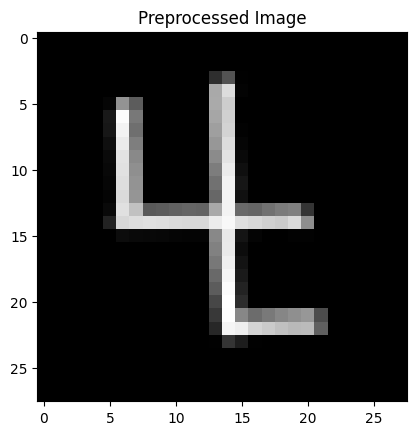

🎉 훈련된 모델이 예측한 숫자는: 1 입니다!

--- 각 숫자별 예측 확률 ---
0:  0.00%
1: 100.00%
2:  0.00%
3:  0.00%
4:  0.00%
5:  0.00%
6:  0.00%
7:  0.00%
8:  0.00%
9:  0.00%


In [155]:
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# 1. 이미지 불러오기 및 흑백(Grayscale) 변환
img = Image.open('/my_number_2.png').convert('L')

# 2. MNIST 사이즈인 28x28 픽셀로 축소
img = img.resize((28, 28))

# 3. 색상 반전 (매우 중요!)
# 우리가 종이에 쓸 때는 '흰 바탕에 검은 글씨'지만,
# MNIST 데이터는 '검은 바탕에 흰 글씨'입니다. 이를 맞춰줍니다.
img = ImageOps.invert(img)

# 화면에 어떻게 변환되었는지 그려서 확인해보기
plt.imshow(img, cmap='gray')
plt.title("Preprocessed Image")
plt.show()

# 4. 넘파이 배열로 변환 후 정규화 (0~1 사이 값으로 만들기)
img_array = np.array(img) / 255.0

# 5. 모델 입력 형태에 맞게 1차원(784)으로 펴주기 (Flatten)
# 데이터가 1장이므로 (1, 784) 형태로 모양을 바꿉니다.
test_image = tf.reshape(img_array, shape=[-1, 784])

# 에러 방지를 위해 데이터 타입을 float64로 명시적으로 맞춰줍니다.
test_image = tf.cast(test_image, tf.float64)

# 6. 학습된 모델에 넣고 예측하기
# 6-1. 모델의 출력값(날것의 점수, Logits)을 구합니다.
logits = model(test_image)

# 6-2. Softmax 함수를 통과시켜 0~1 사이의 확률값으로 변환합니다.
# [0]을 붙여서 2차원 배열(1, 10)을 1차원(10,)으로 꺼내옵니다.
probabilities = tf.nn.softmax(logits).numpy()[0]

# 6-3. 가장 높은 확률을 가진 인덱스(예측값)를 찾습니다.
prediction = np.argmax(probabilities)

print(f"🎉 훈련된 모델이 예측한 숫자는: {prediction} 입니다!\n")

# 6-4. 0부터 9까지 각 숫자별 예측 확률을 텍스트로 출력합니다.
print("--- 각 숫자별 예측 확률 ---")
for i, prob in enumerate(probabilities):
    print(f"{i}: {prob * 100:>5.2f}%")

**Test using hand drawn numbers(pytorch)**

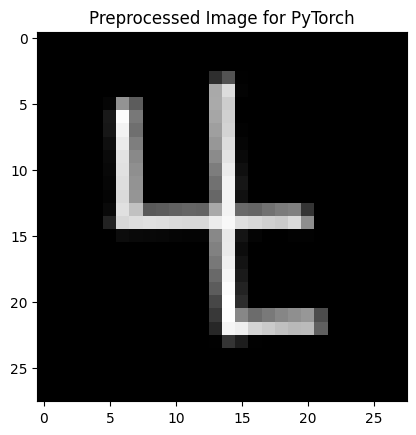

🎉 파이토치 인공지능이 예측한 숫자는: 4 입니다!
--- 각 숫자별 예측 확률 ---
0:  0.00%
1: 15.03%
2:  0.00%
3:  0.00%
4: 58.14%
5:  0.00%
6:  0.00%
7:  0.00%
8: 26.82%
9:  0.00%


In [154]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# 1. 이미지 불러오기 및 흑백, 사이즈 축소, 색상 반전 (이전과 동일)
img = Image.open('/my_number_2.png').convert('L')
img = img.resize((28, 28))
img = ImageOps.invert(img)

# 화면에 출력해서 확인
plt.imshow(img, cmap='gray')
plt.title("Preprocessed Image for PyTorch")
plt.show()

# 2. 파이토치 모델이 학습했던 방식과 '100% 똑같은' 전처리(Transform) 적용
# (훈련 코드에 있던 trans 변수를 그대로 재사용합니다)
test_image = trans(img)

# 3. 배치(Batch) 차원 추가 및 디바이스(GPU/CPU) 이동
# 현재 test_image는 [1, 28, 28] (채널, 높이, 너비) 형태입니다.
# 모델은 한 번에 여러 장을 받는 배치 형태인 [배치크기, 채널, 높이, 너비]를 기대하므로,
# unsqueeze(0)을 통해 맨 앞에 차원을 하나 추가하여 [1, 1, 28, 28]로 만듭니다.
test_image = test_image.unsqueeze(0).to(device)

# 4. 모델 평가 모드 전환 및 예측
layer.eval() # 모델을 평가(테스트) 모드로 전환
with torch.no_grad(): # 미분 계산을 꺼서 메모리 절약
    hypothesis = layer(test_image)

    # Softmax를 적용하여 결과값을 '전체 합이 1인 확률'로 변환합니다.
    # [0]을 붙이는 이유는 2차원 [1, 10] 형태의 배치 결과에서 1차원 [10] 형태의 확률 배열만 쏙 빼오기 위함입니다.
    probabilities = torch.nn.functional.softmax(hypothesis, dim=1)[0]

    # 가장 높은 점수를 받은 인덱스(클래스) 추출
    prediction = torch.argmax(hypothesis, dim=1)

# .item()을 사용하여 파이토치 텐서에서 순수한 파이썬 숫자로 뽑아냅니다.
print(f"🎉 파이토치 인공지능이 예측한 숫자는: {prediction.item()} 입니다!")
print("--- 각 숫자별 예측 확률 ---")
for i, prob in enumerate(probabilities):
    # prob.item()으로 텐서에서 숫자를 꺼내고 100을 곱해 퍼센트로 만듭니다.
    print(f"{i}: {prob.item() * 100:>5.2f}%")